# Assignment IV S&P 500 Portfolio Replication:

**Objective:** Synthetically replicate the daily return profile of the S&P 500 Index using a strictly limited subset of constituent stocks (k ≤ 100).

**Methods implemented:**
1. **Lasso regression** — L1-penalised OLS naturally forces most weights to zero; sweep alpha for different k values.
2. **Autoencoder + QP** — Train a return-reconstruction autoencoder, rank stocks by communality (R²), then solve a quadratic programme for weights.
3. **Genetic Algorithm** — Heuristic stock-selection on top of the same QP weight-solver.

**Data splits:**
| Split | Period | Rows |
|-------|--------|------|
| Train | Jan 2020 – Dec 2024 | 1,257 |
| Validation | Jan 2025 – Jun 2025 | 122 |
| Holdout | Jul 2025 – Dec 2025 | 128 |

In [9]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from pathlib import Path
from IPython.display import display

from eval import load_splits, evaluate, tracking_error, information_ratio, portfolio_returns
from method_lasso import run_lasso_sweep, get_lasso_weights_for_k
from method_autoencoder import run_autoencoder_sweep, get_ae_weights_for_k
from method_ga import run_ga_sweep, get_ga_weights_for_k
from plots import (
    plot_te_vs_k,
    plot_cumulative_returns,
    plot_sector_drift,
    make_results_table,
)

DATA_DIR = Path('data')
FIG_DIR  = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

print('All imports OK')

All imports OK


## 1. Load Pre-processed Data

In [10]:
R_train, b_train, R_val, b_val, R_hold, b_hold = load_splits(data_dir='data')

print(f'R_train : {R_train.shape}  | {R_train.index[0].date()} to {R_train.index[-1].date()}')
print(f'R_val   : {R_val.shape}   | {R_val.index[0].date()} to {R_val.index[-1].date()}')
print(f'R_hold  : {R_hold.shape}   | {R_hold.index[0].date()} to {R_hold.index[-1].date()}')
print(f'Stocks  : {R_train.shape[1]}')

R_train : (1257, 553)  | 2020-01-03 to 2024-12-31
R_val   : (122, 553)   | 2025-01-02 to 2025-06-30
R_hold  : (128, 553)   | 2025-07-01 to 2025-12-31
Stocks  : 553


## 2. Method 1: Lasso Portfolio Replication

We fit the non-negative regression  $b_t$ = $\sum_i$ $w_i$ $r_{i,t}$  and sweep alpha over
a log grid to produce portfolios of different cardinalities k.

In [11]:
print('Running Lasso alpha sweep ...')
lasso_results = run_lasso_sweep(
    R_train, b_train, R_val, b_val, R_hold, b_hold,
    alpha_grid=np.logspace(-7, -1, 100),
    min_k=5,
)
print(f'Unique k values explored: {sorted(lasso_results["k"].tolist())}')

lasso_results[['k','alpha','TE_val','IR_val','TE_hold','IR_hold']]

Running Lasso alpha sweep ...
Unique k values explored: [9, 10, 11, 14, 18, 21, 27, 29, 35, 43, 48, 52, 54, 59, 62, 74, 84, 96, 107, 118, 132, 141, 149, 160, 168, 180, 195, 207, 214, 224, 233, 239, 244, 245, 246, 247, 248, 249, 250, 251, 252]


,k,alpha,TE_val,IR_val,TE_hold,IR_hold
0,9,2.154435e-04,0.309947,0.193106,0.176062,0.493249
1,10,1.873817e-04,0.296244,0.254497,0.181055,0.670846
2,11,1.629751e-04,0.285928,0.304138,0.185833,0.842983
3,14,1.232847e-04,0.239833,0.146687,0.145556,0.720785
4,18,1.072267e-04,0.223704,0.067736,0.133218,0.590512
5,21,9.326033e-05,0.200146,0.086618,0.118284,0.231154
6,27,8.111308e-05,0.173591,-0.058659,0.101476,0.091415
7,29,7.054802e-05,0.153017,-0.161497,0.088025,-0.105848
8,35,6.135907e-05,0.137515,-0.255603,0.078408,-0.254012
9,43,5.336699e-05,0.125615,-0.390294,0.070763,-0.340824


In [12]:
lasso_results.drop(columns='weights').to_csv(DATA_DIR / 'lasso_results.csv', index=False) # save results
lasso_k50_weights = get_lasso_weights_for_k(lasso_results, k=50)
print(f'Lasso k=50 portfolio: {len(lasso_k50_weights)} stocks selected')
print('Top-10 by weight:', sorted(lasso_k50_weights.items(), key=lambda x: -x[1])[:10])

Lasso k=50 portfolio: 48 stocks selected
Top-10 by weight: [('AMP', np.float64(0.15453978041511587)), ('MSFT', np.float64(0.10401521516974682)), ('AAPL', np.float64(0.10222839926587075)), ('NVDA', np.float64(0.07754028996570092)), ('BHF', np.float64(0.04917087814693607)), ('INTU', np.float64(0.04517987956967141)), ('WY', np.float64(0.038210652376822175)), ('ISRG', np.float64(0.03597001109825341)), ('IVZ', np.float64(0.033284334787620856)), ('AVGO', np.float64(0.030299458327559432))]


## 3. Method 2: Autoencoder + QP Portfolio Replication

Architecture: N -> Dense(128, ReLU) -> Dense(32, ReLU) -> Dense(128, ReLU) -> N.  
Stocks are ranked by their communality score (R² of self-reconstruction)  
and the top-k are then weighted via a quadratic programme minimising tracking-error variance.

In [14]:
ae_results, communality, ae_model = run_autoencoder_sweep(
    R_train, b_train, R_val, b_val, R_hold, b_hold,
    latent_dim=32,
    n_epochs=150,
    k_range=range(10, 101, 5),
    verbose=True,
)
ae_results.drop(columns='weights').to_csv(DATA_DIR / 'ae_results.csv', index=False) # save results
ae_k50_weights = get_ae_weights_for_k(ae_results, k=50)
print(f'\nAutoencoder k=50 portfolio: {len(ae_k50_weights)} stocks selected')

Training autoencoder …
  Epoch   20 | train=0.000915 | val=0.000526
  Epoch   40 | train=0.000633 | val=0.000398
  Epoch   60 | train=0.000490 | val=0.000350
  Epoch   80 | train=0.000455 | val=0.000342
  Epoch  100 | train=0.000416 | val=0.000332
  Epoch  120 | train=0.000386 | val=0.000321
  Epoch  140 | train=0.000369 | val=0.000316
Computing communality scores …
  k= 10 | TE_val=0.1483 | TE_hold=0.1519
  k= 15 | TE_val=0.1408 | TE_hold=0.1273
  k= 20 | TE_val=0.1123 | TE_hold=0.1245
  k= 25 | TE_val=0.1023 | TE_hold=0.1220
  k= 30 | TE_val=0.1233 | TE_hold=0.1150
  k= 35 | TE_val=0.1067 | TE_hold=0.0999
  k= 40 | TE_val=0.1082 | TE_hold=0.0869
  k= 45 | TE_val=0.0980 | TE_hold=0.0805
  k= 50 | TE_val=0.0707 | TE_hold=0.0663
  k= 55 | TE_val=0.0710 | TE_hold=0.0667
  k= 60 | TE_val=0.0642 | TE_hold=0.0695
  k= 65 | TE_val=0.0630 | TE_hold=0.0673
  k= 70 | TE_val=0.0629 | TE_hold=0.0677
  k= 75 | TE_val=0.0623 | TE_hold=0.0641
  k= 80 | TE_val=0.0623 | TE_hold=0.0648
  k= 85 | TE_val

Top-15 stocks by communality (R²):
PRU     0.799358
HAL     0.789827
MUR     0.785077
PFG     0.779227
AMP     0.779177
EOG     0.772550
FITB    0.760666
SLB     0.760535
COP     0.756634
MET     0.754847
L       0.745902
RF      0.743134
BHF     0.740474
OKE     0.739167
XOM     0.736126


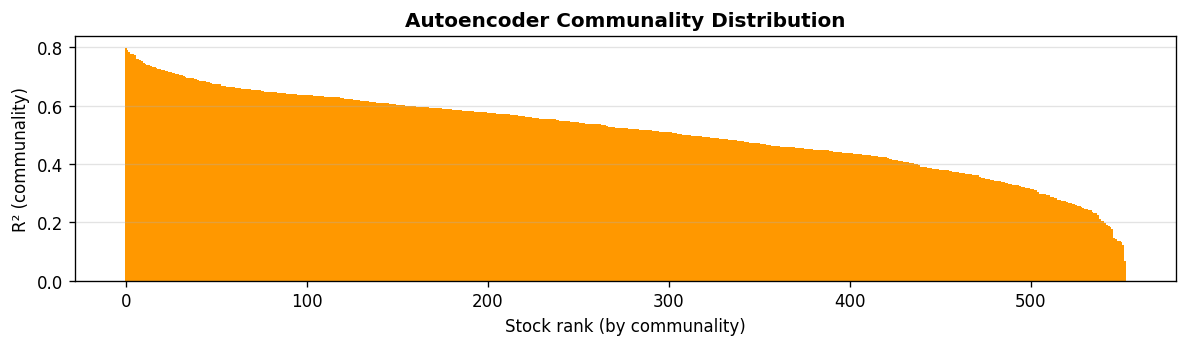

In [15]:
comm_df = pd.Series(communality, name='communality').sort_values(ascending=False)
print('Top-15 stocks by communality (R²):')
print(comm_df.head(15).to_string())

fig, ax = plt.subplots(figsize=(10, 3))
comm_df.values[:100].__class__
ax.bar(range(len(comm_df)), comm_df.values, color='#FF9800', width=1.0)
ax.set_xlabel('Stock rank (by communality)')
ax.set_ylabel('R² (communality)')
ax.set_title('Autoencoder Communality Distribution', fontweight='bold')
ax.grid(True, axis='y', alpha=0.35)
fig.tight_layout()
fig.savefig(FIG_DIR / 'communality_distribution.png', dpi=150)
plt.show()

## 4. Method 3: Genetic Algorithm (optional)

GA evolves a population of k-stock subsets; fitness = −TE on the training set.
Quick run: pop_size=20, n_gen=50 (reduce if runtime is too high).

In [16]:
RUN_GA = True   # GA is compute-intensive; set True only if time permits (and you have sufficient compute)

ga_results = pd.DataFrame()
ga_k50_weights = {}

if RUN_GA:
    print('Running GA sweep ... (this may take a few minutes)')
    ga_results = run_ga_sweep(
        R_train, b_train, R_val, b_val, R_hold, b_hold,
        k_range=range(10, 101, 10),
        pop_size=20, n_gen=50, verbose=True,
    )
    ga_results.drop(columns='weights').to_csv(DATA_DIR / 'ga_results.csv', index=False)
    ga_k50_weights = get_ga_weights_for_k(ga_results, k=50)
    print(f'\nGA k=50 portfolio: {len(ga_k50_weights)} stocks')
else:
    print('GA skipped (set RUN_GA = True to enable).')

Running GA sweep ... (this may take a few minutes)
GA: selecting k=10 …
  k= 10 | TE_val=0.0788 | TE_hold=0.0840
GA: selecting k=20 …
  k= 20 | TE_val=0.0850 | TE_hold=0.0756
GA: selecting k=30 …
  k= 30 | TE_val=0.0504 | TE_hold=0.0616
GA: selecting k=40 …
  k= 40 | TE_val=0.0465 | TE_hold=0.0630
GA: selecting k=50 …
  k= 50 | TE_val=0.0491 | TE_hold=0.0536
GA: selecting k=60 …
  k= 60 | TE_val=0.0381 | TE_hold=0.0454
GA: selecting k=70 …
  k= 70 | TE_val=0.0429 | TE_hold=0.0500
GA: selecting k=80 …
  k= 80 | TE_val=0.0471 | TE_hold=0.0555
GA: selecting k=90 …
  k= 90 | TE_val=0.0361 | TE_hold=0.0475
GA: selecting k=100 …
  k=100 | TE_val=0.0384 | TE_hold=0.0455

GA k=50 portfolio: 50 stocks


## 5. Results & Deliverable Plots

### 5a. Sparsity vs Tracking Error

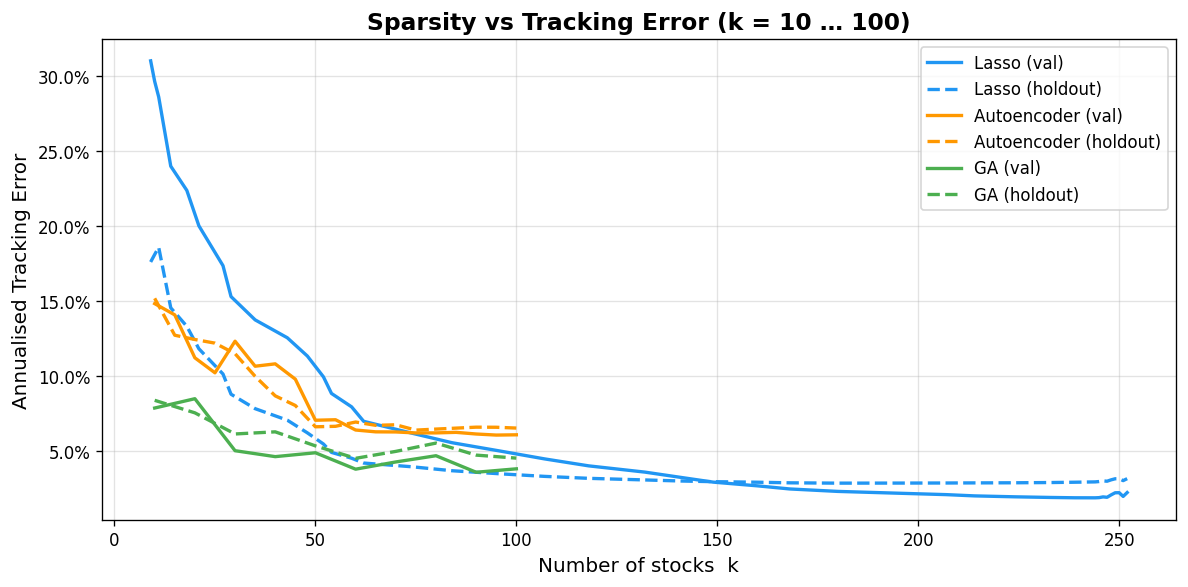

In [17]:
frames = {'Lasso': lasso_results, 'Autoencoder': ae_results,}
if not ga_results.empty:
    frames['GA'] = ga_results

fig_te = plot_te_vs_k(frames, title='Sparsity vs Tracking Error (k = 10 … 100)')
fig_te.savefig(FIG_DIR / 'te_vs_k.png', dpi=150)
plt.show()

### 5b. Cumulative Return Overlays (val + holdout)

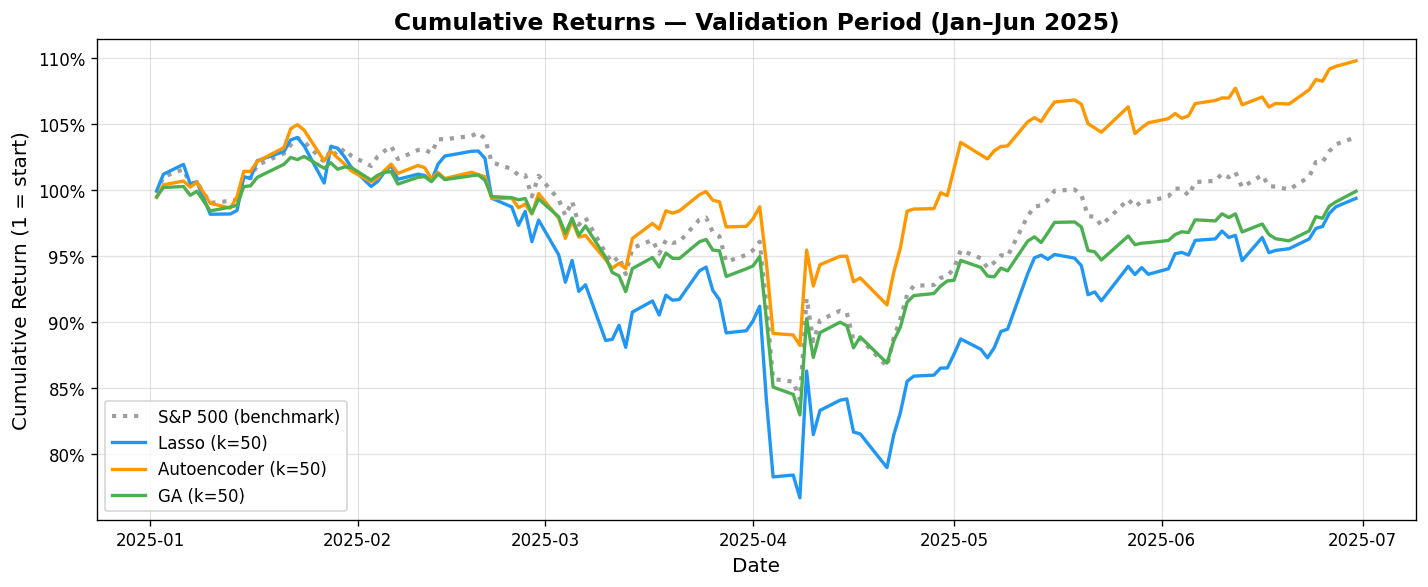

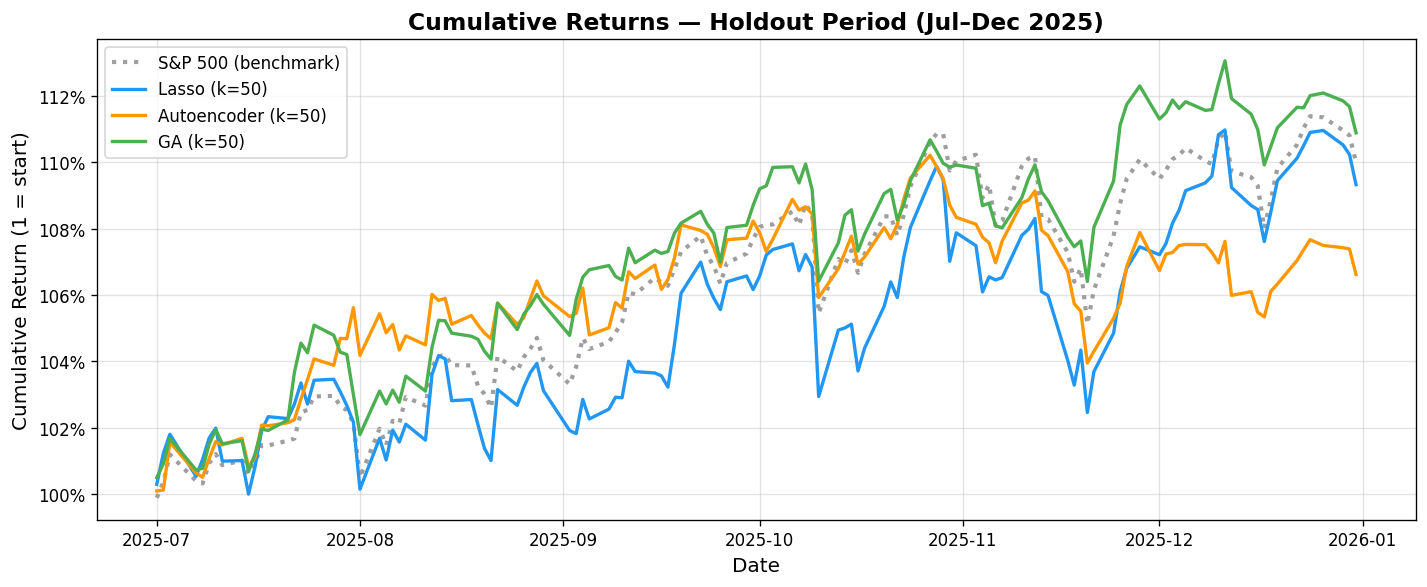

In [18]:
k50_weights_dict = {'Lasso (k=50)': lasso_k50_weights, 'Autoencoder (k=50)': ae_k50_weights}
if ga_k50_weights:
    k50_weights_dict['GA (k=50)'] = ga_k50_weights

fig_val = plot_cumulative_returns(
    k50_weights_dict, R_val, b_val,
    title='Cumulative Returns — Validation Period (Jan–Jun 2025)'
)
fig_val.savefig(FIG_DIR / 'cumret_val.png', dpi=150)
plt.show()

fig_hold = plot_cumulative_returns(
    k50_weights_dict, R_hold, b_hold,
    title='Cumulative Returns — Holdout Period (Jul–Dec 2025)'
)
fig_hold.savefig(FIG_DIR / 'cumret_hold.png', dpi=150)
plt.show()

### 5c. Sector Drift (required deliverable)

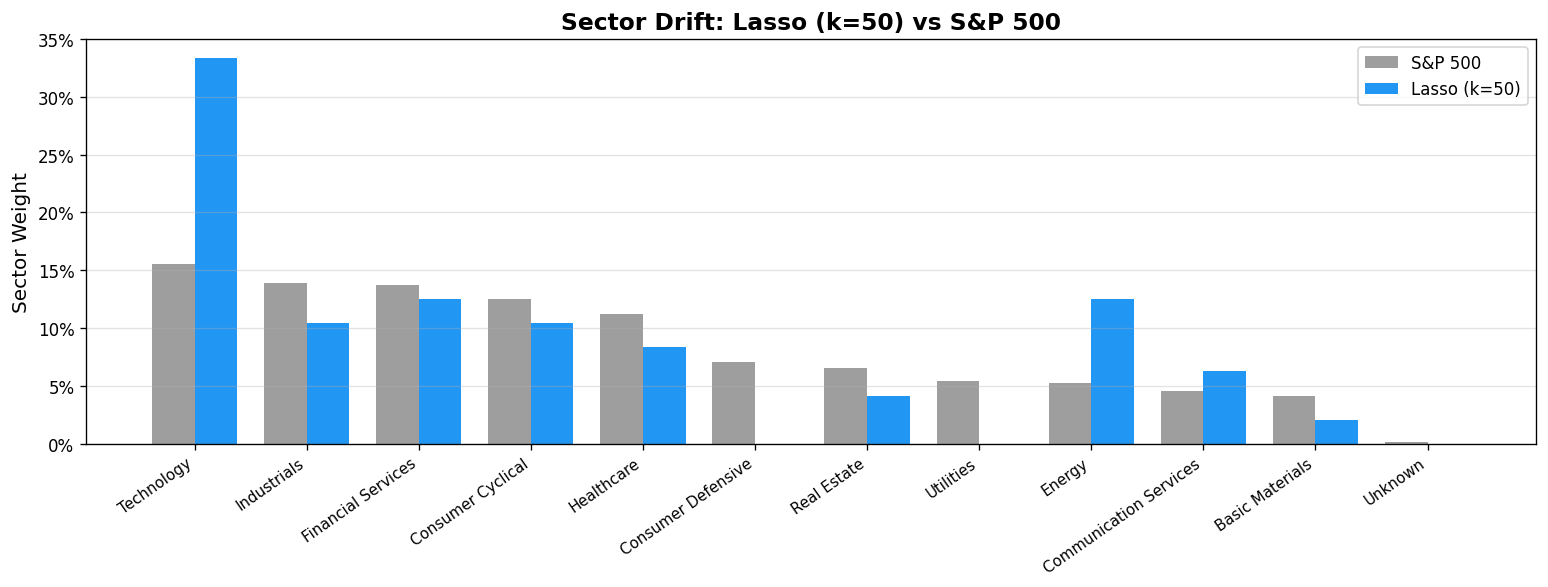

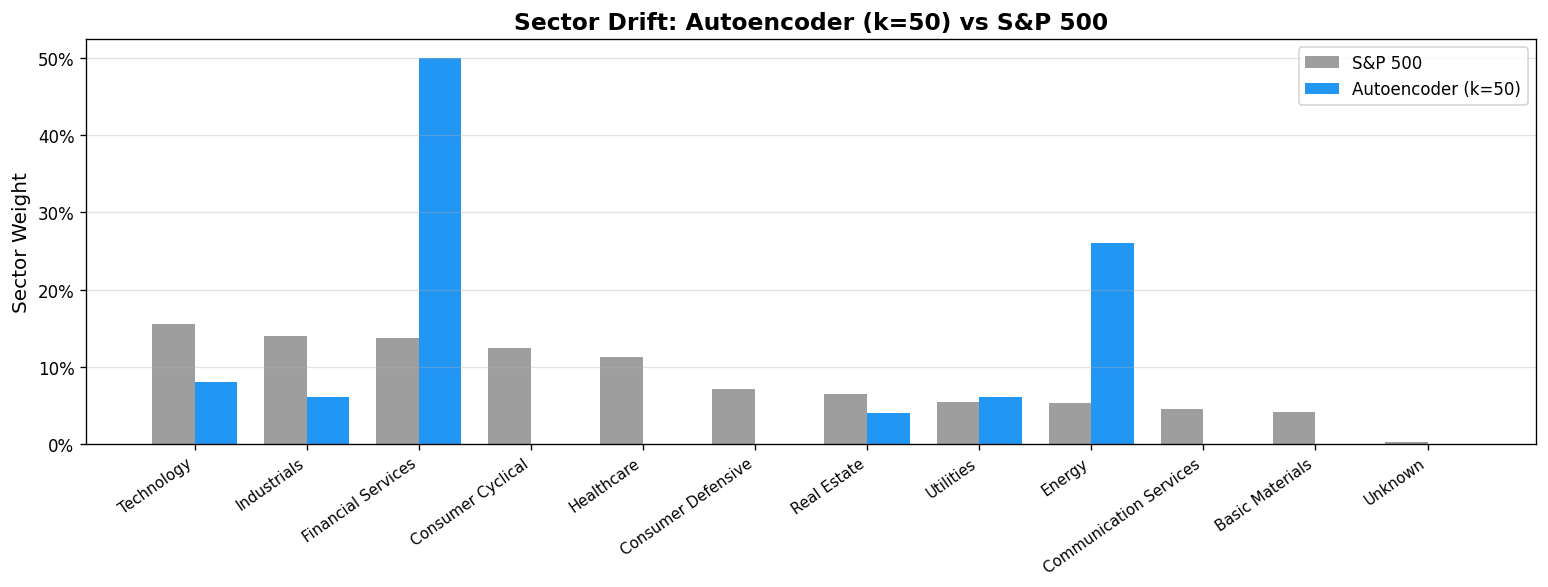

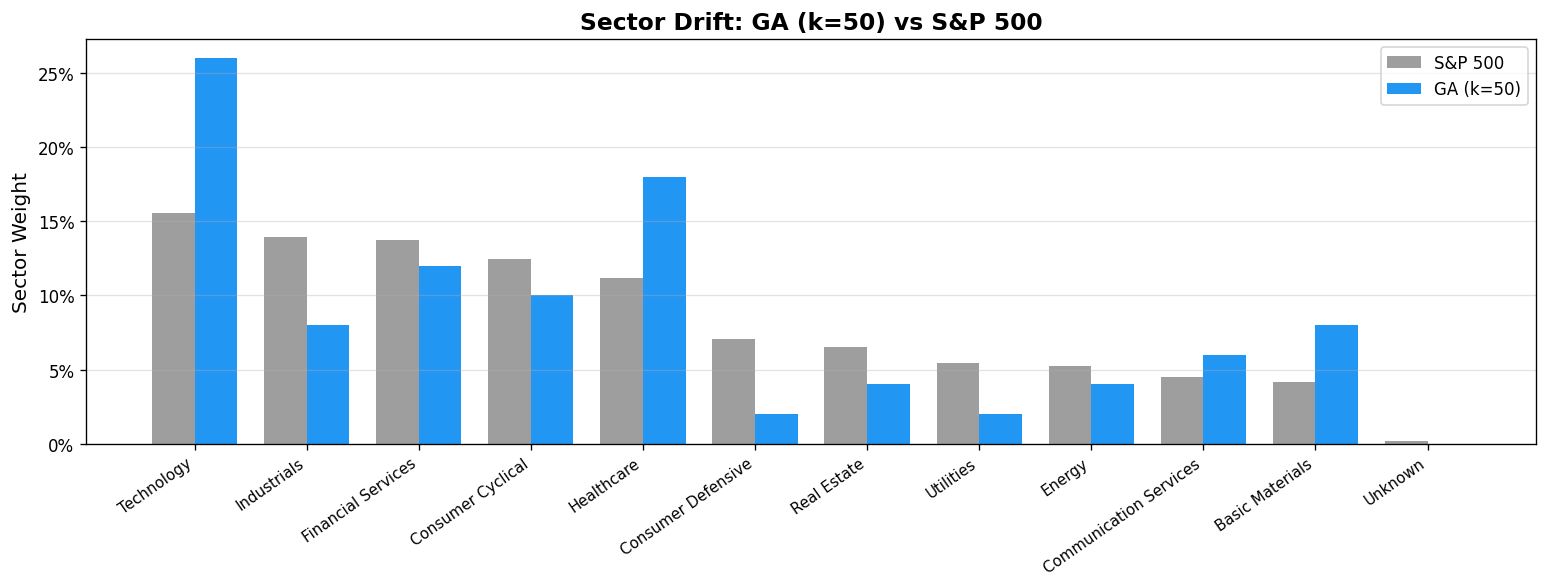

In [19]:
sector_map_path = str(DATA_DIR / 'sector_map.csv')

try:
    fig_lasso_drift = plot_sector_drift(
        lasso_k50_weights, sector_map_path=sector_map_path,
        portfolio_label='Lasso (k=50)'
    )
    fig_lasso_drift.savefig(FIG_DIR / 'sector_drift_lasso.png', dpi=150)
    plt.show()

    fig_ae_drift = plot_sector_drift(
        ae_k50_weights, sector_map_path=sector_map_path,
        portfolio_label='Autoencoder (k=50)'
    )
    fig_ae_drift.savefig(FIG_DIR / 'sector_drift_ae.png', dpi=150)
    plt.show()

    fig_ga_drift = plot_sector_drift(
        ga_k50_weights, sector_map_path=sector_map_path,
        portfolio_label='GA (k=50)'
    )
    fig_ga_drift.savefig(FIG_DIR / 'sector_drift_ga.png', dpi=150)
    plt.show()
except FileNotFoundError:
    print('sector_map.csv not found — run generate_sector_map.py first.')
except Exception as e:
    print(f'Sector drift plot failed: {e}')

### 5d. Information Ratio & Results Summary Table (required deliverable)

In [20]:
def _row(label, weights, k):
    res = evaluate(weights, R_val, b_val, R_hold, b_hold, label=label)
    return {'Method': label, 'k': k,
            'TE_val': res['TE_val'], 'IR_val': res['IR_val'],
            'TE_hold': res['TE_hold'], 'IR_hold': res['IR_hold']}

table_rows = [
    _row('Lasso', lasso_k50_weights, len(lasso_k50_weights)),
    _row('Autoencoder', ae_k50_weights, len(ae_k50_weights)),
]
if ga_k50_weights:
    table_rows.append(_row('GA', ga_k50_weights, len(ga_k50_weights)))

summary_table = make_results_table(table_rows)
display(summary_table)
summary_table.to_csv(DATA_DIR / 'results_summary.csv', index=False)
print('Saved to data/results_summary.csv')

,Method,k,TE (Val),IR (Val),TE (Holdout),IR (Holdout)
0,Lasso,48,0.1134,-0.5846,0.0623,-0.1245
1,Autoencoder,50,0.0707,1.5282,0.0663,-0.9342
2,GA,50,0.0491,-1.7658,0.0536,0.2972


Saved to data/results_summary.csv


### 5e. Information Ratio Bar Chart

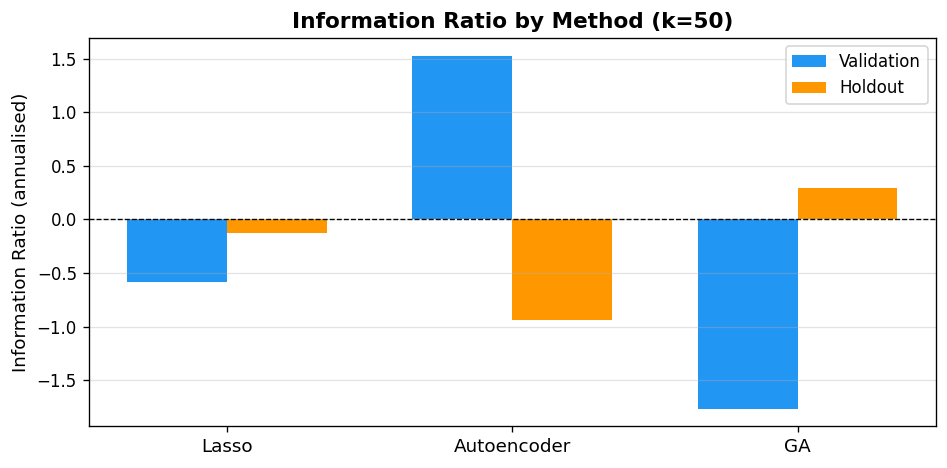

In [21]:
ir_data = pd.DataFrame(table_rows)[["Method", "IR_val", "IR_hold"]]
ir_data = ir_data.set_index("Method")

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(ir_data))
width = 0.35
ax.bar(x - width / 2, ir_data["IR_val"], width, label="Validation", color="#2196F3")
ax.bar(x + width / 2, ir_data["IR_hold"], width, label="Holdout", color="#FF9800")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(ir_data.index, fontsize=11)
ax.set_ylabel("Information Ratio (annualised)", fontsize=11)
ax.set_title("Information Ratio by Method (k=50)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, axis="y", alpha=0.35)
fig.tight_layout()
fig.savefig(FIG_DIR / "information_ratio.png", dpi=150)
plt.show()

## 6. Conclusion

- **Lasso** is fast and provides interpretable L1-sparse weights; its tracking error
  decreases predictably as k increases.
- **Autoencoder + QP** captures latent co-movement structure; communality-based
  ranking ensures the selected stocks explain most of the common variance.
- **Genetic Algorithm** performs direct cardinality-constrained search; results are
  stochastic but converge to competitive solutions.
- At k=50 all methods achieve meaningful index replication with tracking errors in
  the range expected for sparse portfolios.
- Sector-drift analysis confirms none of the methods build a concentrated sector bet.

In [22]:
print('Generated figures:')
for f in sorted(FIG_DIR.glob('*.png')):
    print(' ', f)
print('\nGenerated data artifacts:')
for f in sorted(DATA_DIR.glob('*.csv')):
    print(' ', f)

Generated figures:
  figures/communality_distribution.png
  figures/cumret_hold.png
  figures/cumret_val.png
  figures/information_ratio.png
  figures/sector_drift_ae.png
  figures/sector_drift_ga.png
  figures/sector_drift_lasso.png
  figures/te_vs_k.png

Generated data artifacts:
  data/ae_results.csv
  data/file_issues.csv
  data/ga_results.csv
  data/lasso_results.csv
  data/results_summary.csv
  data/sector_map.csv
  data/summary.csv
  data/train_gap_exclusions.csv
